In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import (
    GroupShuffleSplit,
    StratifiedGroupKFold,
    GridSearchCV
)

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)

In [18]:
uploaded = files.upload()

filename = next(iter(uploaded))
df = pd.read_csv(filename)

df.head()

Saving plant_health_data.csv to plant_health_data.csv


,Timestamp,Plant_ID,Soil_Moisture,Ambient_Temperature,Soil_Temperature,Humidity,Light_Intensity,Soil_pH,Nitrogen_Level,Phosphorus_Level,Potassium_Level,Chlorophyll_Content,Electrochemical_Signal,Plant_Health_Status
0,2024-10-03 10:54:53.407995,1,27.521109,22.240245,21.900435,55.291904,556.172805,5.581955,10.003650,45.806852,39.076199,35.703006,0.941402,High Stress
1,2024-10-03 16:54:53.407995,1,14.835566,21.706763,18.680892,63.949181,596.136721,7.135705,30.712562,25.394393,17.944826,27.993296,0.164899,High Stress
2,2024-10-03 22:54:53.407995,1,17.086362,21.180946,15.392939,67.837956,591.124627,5.656852,29.337002,27.573892,35.706530,43.646308,1.081728,High Stress
3,2024-10-04 04:54:53.407995,1,15.336156,22.593302,22.778394,58.190811,241.412476,5.584523,16.966621,26.180705,26.257746,37.838095,1.186088,High Stress
4,2024-10-04 10:54:53.407995,1,39.822216,28.929001,18.100937,63.772036,444.493830,5.919707,10.944961,37.898907,37.654483,48.265812,1.609805,High Stress


In [19]:
print("Number of rows and columns:", df.shape)

print("\nColumn names:")
print(df.columns)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nHealth status counts:")
print(df["Plant_Health_Status"].value_counts())

Number of rows and columns: (1200, 14)

Column names:
Index(['Timestamp', 'Plant_ID', 'Soil_Moisture', 'Ambient_Temperature',
       'Soil_Temperature', 'Humidity', 'Light_Intensity', 'Soil_pH',
       'Nitrogen_Level', 'Phosphorus_Level', 'Potassium_Level',
       'Chlorophyll_Content', 'Electrochemical_Signal', 'Plant_Health_Status'],
      dtype='object')

Missing values:
Timestamp                 0
Plant_ID                  0
Soil_Moisture             0
Ambient_Temperature       0
Soil_Temperature          0
Humidity                  0
Light_Intensity           0
Soil_pH                   0
Nitrogen_Level            0
Phosphorus_Level          0
Potassium_Level           0
Chlorophyll_Content       0
Electrochemical_Signal    0
Plant_Health_Status       0
dtype: int64

Duplicate rows:
0

Health status counts:
Plant_Health_Status
High Stress        500
Moderate Stress    401
Healthy            299
Name: count, dtype: int64


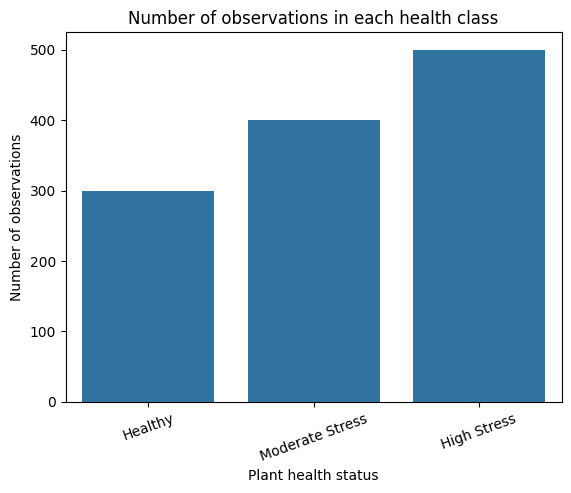

In [20]:
sns.countplot(
    data=df,
    x="Plant_Health_Status",
    order=["Healthy", "Moderate Stress", "High Stress"]
)

plt.title("Number of observations in each health class")
plt.xlabel("Plant health status")
plt.ylabel("Number of observations")
plt.xticks(rotation=20)
plt.show()

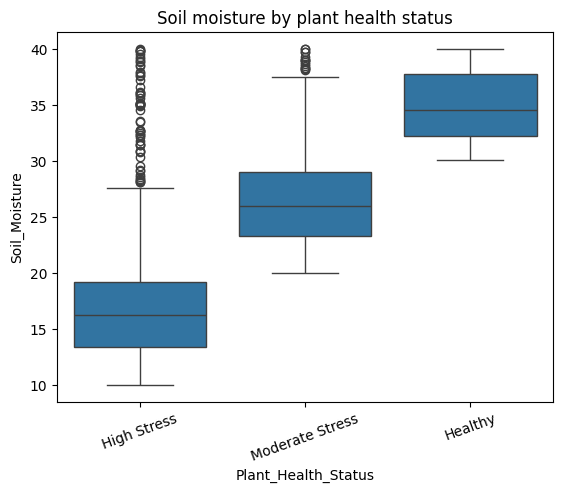

In [21]:
sns.boxplot(
    data=df,
    x="Plant_Health_Status",
    y="Soil_Moisture"
)

plt.title("Soil moisture by plant health status")
plt.xticks(rotation=20)
plt.show()

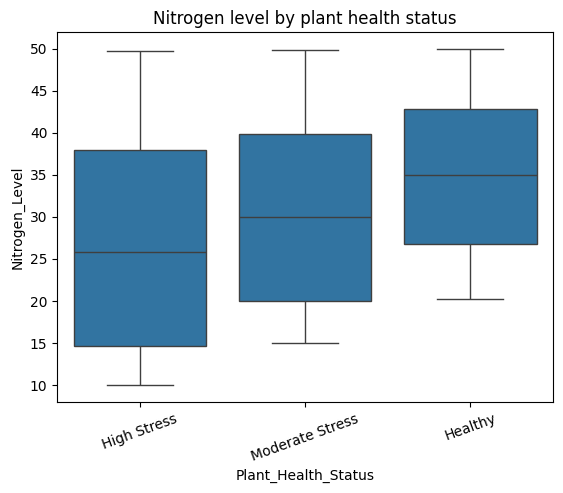

In [22]:
sns.boxplot(
    data=df,
    x="Plant_Health_Status",
    y="Nitrogen_Level"
)

plt.title("Nitrogen level by plant health status")
plt.xticks(rotation=20)
plt.show()

## Outlier Detection and Handling using IQR Method

Outliers are unusually high or low numerical values that may affect data analysis and machine learning models.

The Interquartile Range (IQR) method is used to identify potential outliers in numerical features.

In [24]:
numeric_columns = df.select_dtypes(include=["number"]).columns.tolist()

# Plant_ID is an identifier, so it should not be used for outlier detection
if "Plant_ID" in numeric_columns:
    numeric_columns.remove("Plant_ID")

print("Numerical features used for outlier detection:")
print(numeric_columns)

# Plant_ID is an identifier, so it should not be used for outlier detection
if "Plant_ID" in numeric_columns:
    numeric_columns.remove("Plant_ID")

print("Numerical features used for outlier detection:")
print(numeric_columns)

Numerical features used for outlier detection:
['Soil_Moisture', 'Ambient_Temperature', 'Soil_Temperature', 'Humidity', 'Light_Intensity', 'Soil_pH', 'Nitrogen_Level', 'Phosphorus_Level', 'Potassium_Level', 'Chlorophyll_Content', 'Electrochemical_Signal']
Numerical features used for outlier detection:
['Soil_Moisture', 'Ambient_Temperature', 'Soil_Temperature', 'Humidity', 'Light_Intensity', 'Soil_pH', 'Nitrogen_Level', 'Phosphorus_Level', 'Potassium_Level', 'Chlorophyll_Content', 'Electrochemical_Signal']


In [25]:
outlier_summary = []

for column in numeric_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    outlier_summary.append({
        "Feature": column,
        "Outlier Count": len(outliers),
        "Lower Bound": round(lower_bound, 2),
        "Upper Bound": round(upper_bound, 2)
    })

outlier_summary_df = pd.DataFrame(outlier_summary)

outlier_summary_df

,Feature,Outlier Count,Lower Bound,Upper Bound
0,Soil_Moisture,0,-5.73,55.23
1,Ambient_Temperature,0,12.19,35.95
2,Soil_Temperature,0,9.49,30.46
3,Humidity,0,23.87,85.60
4,Light_Intensity,0,-175.01,1403.37
5,Soil_pH,0,4.52,8.54
6,Nitrogen_Level,0,-9.65,70.09
7,Phosphorus_Level,0,-7.96,68.99
8,Potassium_Level,0,-11.20,70.89
9,Chlorophyll_Content,0,5.31,64.39


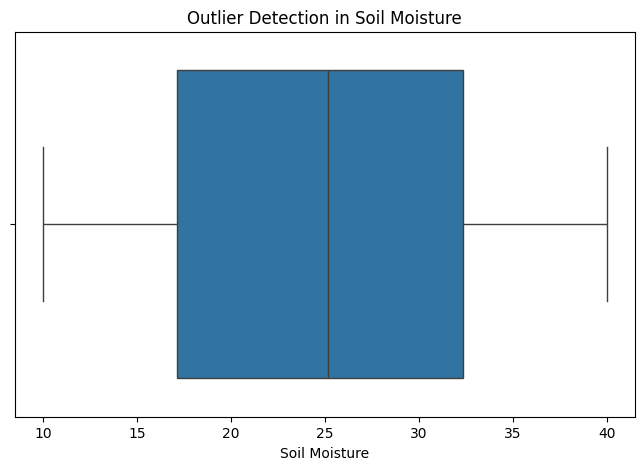

In [26]:
plt.figure(figsize=(8, 5))

sns.boxplot(x=df["Soil_Moisture"])

plt.title("Outlier Detection in Soil Moisture")
plt.xlabel("Soil Moisture")

plt.show()

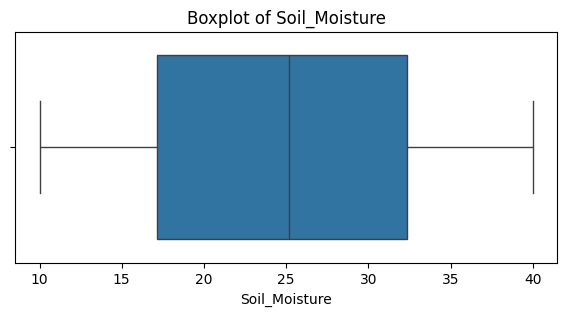

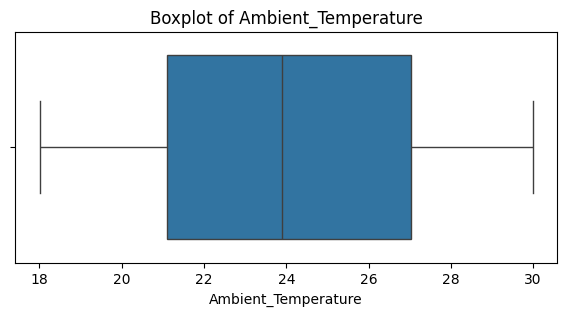

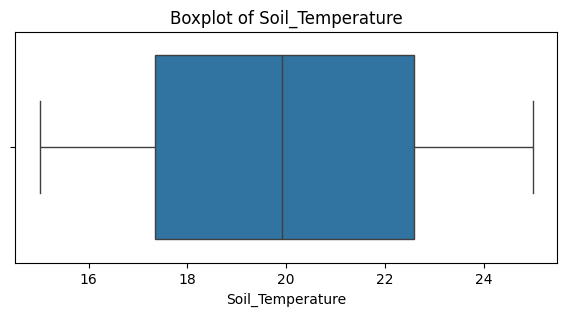

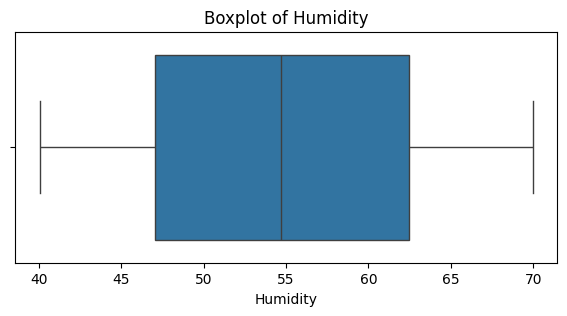

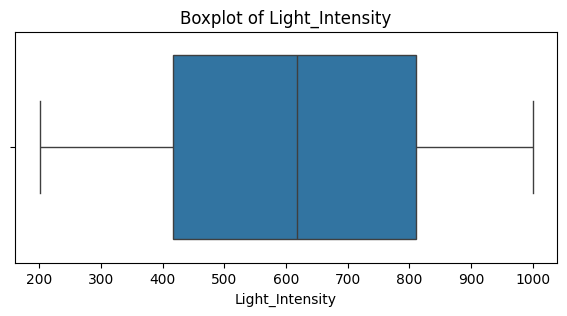

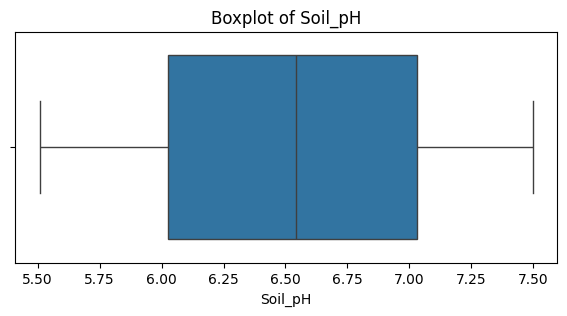

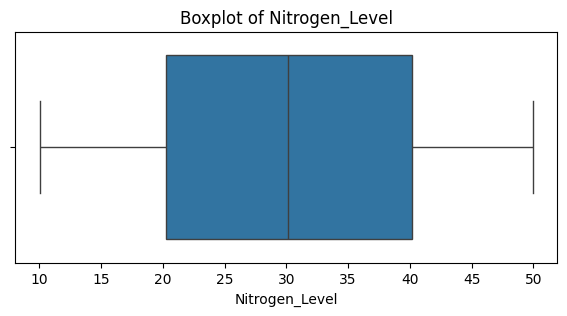

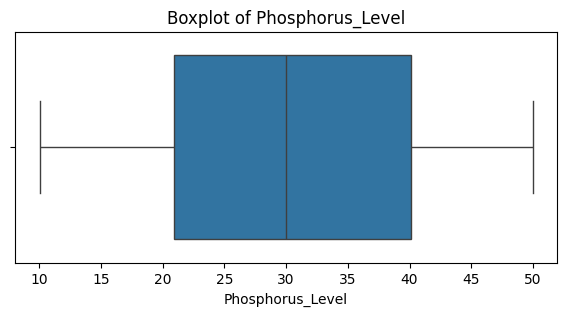

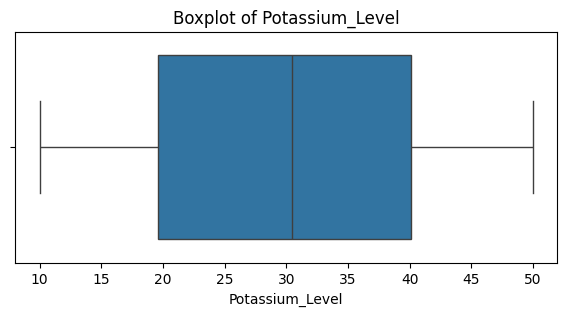

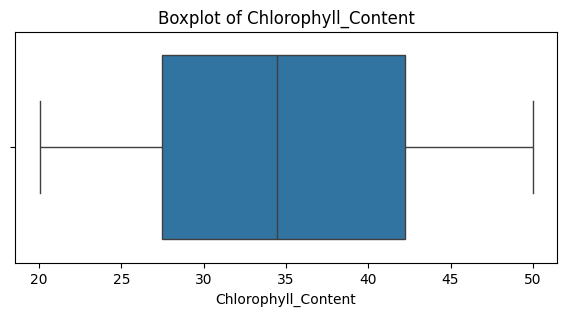

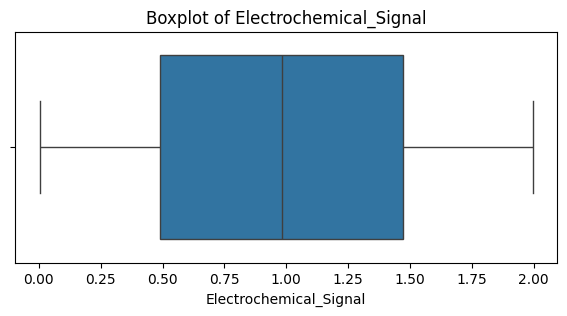

In [27]:
for column in numeric_columns:
    plt.figure(figsize=(7, 3))

    sns.boxplot(x=df[column])

    plt.title(f"Boxplot of {column}")
    plt.xlabel(column)

    plt.show()

### Outlier Analysis Conclusion

The IQR method was applied to all numerical features to identify potential outliers.

No outliers were detected in any of the numerical features. The boxplots also confirm that there are no data points outside the whiskers.

Therefore, no outlier removal was performed because removing valid observations unnecessarily could result in information loss.

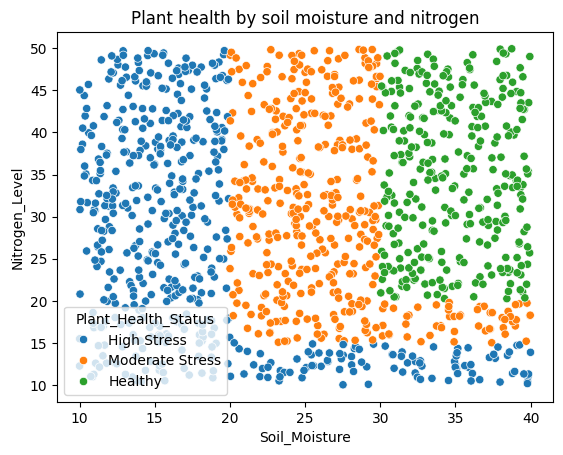

In [28]:
sns.scatterplot(
    data=df,
    x="Soil_Moisture",
    y="Nitrogen_Level",
    hue="Plant_Health_Status"
)

plt.title("Plant health by soil moisture and nitrogen")
plt.show()

In [29]:
target_column = "Plant_Health_Status"

y = df[target_column]
groups = df["Plant_ID"]

X = df.drop(
    columns=[
        target_column,
        "Plant_ID",
        "Timestamp"
    ]
)

print("Input columns:")
print(X.columns)

print("\nTarget classes:")
print(y.unique())

Input columns:
Index(['Soil_Moisture', 'Ambient_Temperature', 'Soil_Temperature', 'Humidity',
       'Light_Intensity', 'Soil_pH', 'Nitrogen_Level', 'Phosphorus_Level',
       'Potassium_Level', 'Chlorophyll_Content', 'Electrochemical_Signal'],
      dtype='object')

Target classes:
['High Stress' 'Moderate Stress' 'Healthy']


In [30]:
splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_index, test_index = next(
    splitter.split(X, y, groups=groups)
)

X_train = X.iloc[train_index]
X_test = X.iloc[test_index]

y_train = y.iloc[train_index]
y_test = y.iloc[test_index]

groups_train = groups.iloc[train_index]
groups_test = groups.iloc[test_index]

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

print("Training plants:", sorted(groups_train.unique()))
print("Testing plants:", sorted(groups_test.unique()))

Training rows: 960
Testing rows: 240
Training plants: [np.int64(1), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(10)]
Testing plants: [np.int64(2), np.int64(9)]


In [31]:
tree_pipeline = Pipeline([
    (
        "missing_values",
        SimpleImputer(strategy="median")
    ),
    (
        "model",
        DecisionTreeClassifier(
            random_state=42,
            class_weight="balanced"
        )
    )
])

In [34]:
tree_parameters = {
    "model__max_depth": [2, 3, 4, 5, 6, None],
    "model__min_samples_leaf": [1, 2, 5, 10],
    "model__criterion": ["gini", "entropy"]
}

In [35]:
svm_pipeline = Pipeline([
    (
        "missing_values",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    ),
    (
        "model",
        SVC(class_weight="balanced")
    )
])

In [36]:
svm_parameters = {
    "model__C": [0.1, 1, 10, 100],
    "model__gamma": ["scale", 0.01, 0.1, 1],
    "model__kernel": ["rbf"]
}

In [37]:
cross_validation = StratifiedGroupKFold(
    n_splits=4,
    shuffle=True,
    random_state=42
)

In [38]:
tree_search = GridSearchCV(
    estimator=tree_pipeline,
    param_grid=tree_parameters,
    scoring="f1_macro",
    cv=cross_validation,
    n_jobs=-1
)

tree_search.fit(
    X_train,
    y_train,
    groups=groups_train
)

print("Best Decision Tree settings:")
print(tree_search.best_params_)

print("Decision Tree cross-validation F1:")
print(tree_search.best_score_)

Best Decision Tree settings:
{'model__criterion': 'gini', 'model__max_depth': 4, 'model__min_samples_leaf': 1}
Decision Tree cross-validation F1:
0.9981406882618576


In [39]:
svm_search = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=svm_parameters,
    scoring="f1_macro",
    cv=cross_validation,
    n_jobs=-1
)

svm_search.fit(
    X_train,
    y_train,
    groups=groups_train
)

print("Best SVM settings:")
print(svm_search.best_params_)

print("SVM cross-validation F1:")
print(svm_search.best_score_)

Best SVM settings:
{'model__C': 100, 'model__gamma': 0.01, 'model__kernel': 'rbf'}
SVM cross-validation F1:
0.8484942390538242


In [40]:
tree_predictions = tree_search.predict(X_test)
svm_predictions = svm_search.predict(X_test)

results = pd.DataFrame({
    "Model": ["Decision Tree", "SVM"],
    "Accuracy": [
        accuracy_score(y_test, tree_predictions),
        accuracy_score(y_test, svm_predictions)
    ],
    "Macro F1": [
        f1_score(y_test, tree_predictions, average="macro"),
        f1_score(y_test, svm_predictions, average="macro")
    ]
})

results

,Model,Accuracy,Macro F1
0,Decision Tree,0.991667,0.990817
1,SVM,0.850000,0.842870


In [41]:
print("DECISION TREE")
print(
    classification_report(
        y_test,
        tree_predictions,
        zero_division=0
    )
)

print("\nSVM")
print(
    classification_report(
        y_test,
        svm_predictions,
        zero_division=0
    )
)

DECISION TREE
                 precision    recall  f1-score   support

        Healthy       1.00      0.98      0.99        64
    High Stress       0.99      1.00      1.00       110
Moderate Stress       0.98      0.98      0.98        66

       accuracy                           0.99       240
      macro avg       0.99      0.99      0.99       240
   weighted avg       0.99      0.99      0.99       240


SVM
                 precision    recall  f1-score   support

        Healthy       0.87      0.86      0.87        64
    High Stress       0.96      0.85      0.90       110
Moderate Stress       0.70      0.83      0.76        66

       accuracy                           0.85       240
      macro avg       0.84      0.85      0.84       240
   weighted avg       0.86      0.85      0.85       240



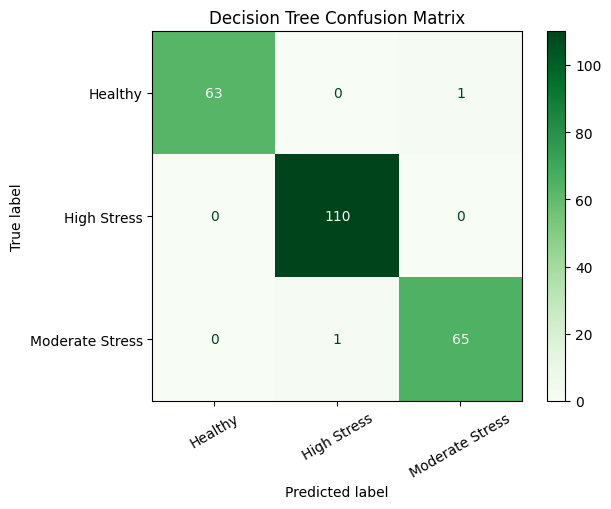

In [42]:
ConfusionMatrixDisplay.from_estimator(
    tree_search.best_estimator_,
    X_test,
    y_test,
    cmap="Greens",
    xticks_rotation=30
)

plt.title("Decision Tree Confusion Matrix")
plt.show()

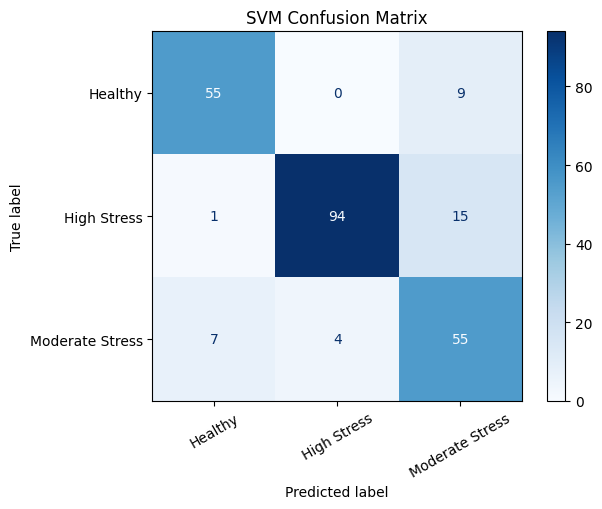

In [43]:
ConfusionMatrixDisplay.from_estimator(
    svm_search.best_estimator_,
    X_test,
    y_test,
    cmap="Blues",
    xticks_rotation=30
)

plt.title("SVM Confusion Matrix")
plt.show()